算术平均 Arithmetic Mean
$$
\bar{x} = \mu = \frac{1}{n}\sum_{i=1}^n x_i
$$


In [1]:
import numpy as np
np.set_printoptions(linewidth=np.inf)
np.set_printoptions(suppress=True)

data = np.array([1, 2, 3, 4, 5, 4, 3, 2, 1])

arithmetic_mean = data.mean()
print(f'算术平均值 = {arithmetic_mean}')


算术平均值 = 2.7777777777777777


几何平均 Geometric Mean
$$
\bar{x} = (\prod_{i=1}^n x_i)^{\frac{1}{n}}
$$

In [2]:
geometric_mean = data.prod() ** (1 / data.size)
print(f'几何平均 = {geometric_mean}')


几何平均 = 2.423131275401765


$$
\text{方差 (Variance): 统计量, 用于衡量数据点与数据均值之间的差异程度或者离散程度} \\
\sigma^2 = \dfrac{1}{N} \sum_{i=1}^n (x_i - \mu)^2 \\ \quad \\

\mu \text{ 是总体的均值} \\ \quad \\

\text{样本方差 (Sample Variance): 统计量, 用于衡量样本数据点与样本均值之间的差异程度} \\
S^2 = \dfrac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2 \\ \quad \\

\bar{x} \text{ 是样本的均值} \\
\text{这里的-1是贝塞尔校正项 (Bessel's Correction), 样本数据仅是总体的一个子集, 它不包含所有信息} \\
\text{因此样本方差往往会低估总体方差, 为了弥补这一差异, 引入了贝塞尔校正项, 将除数从n改为n-1, 从而更准确地估计总体方差} \\ \quad \\

\text{标准差 (Standard Deviation): 统计量, 是方差的算术平方根, 用于衡量数据点偏离数据均值的距离, 同样有总体标准差和样本标准差} \\
\sigma = \sqrt{\sigma^2} = \sqrt{\dfrac{1}{N} \sum_{i=1}^n (x_i - \mu)^2} \\ \quad \\
\sigma = \sqrt{\sigma^2} = \sqrt{\dfrac{1}{n-1} \sum_{i=1}^n (x_i - \mu)^2} \\ \quad \\
$$

In [3]:
variance = data.var()
print(f'方差 = {variance}')

sample_variance = data.var(ddof=1)
print(f'样本方差 = {sample_variance}')

stdev = data.std()
print(f'标准差 = {stdev}')

sample_stdev = data.std(ddof=1)
print(f'样本标准差 = {sample_stdev}')

方差 = 1.7283950617283952
样本方差 = 1.9444444444444446
标准差 = 1.314684396244359
样本标准差 = 1.3944333775567928


$$
\text{正态分布的概率密度函数} \\
f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}
\quad \\
\mu: \text{均值} \\
\sigma^2: \text{方差} \\
\text{标准正态分布: } \mu = 0, \sigma^2 = 1
$$

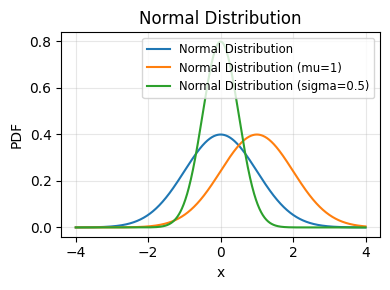

In [4]:
from matplotlib import pyplot as plt
import scipy.stats as stats

def plot_nicely():
    for ax in plt.gcf().get_axes():
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize='small')
    plt.tight_layout()

normal_distribution = stats.norm()
x = np.linspace(-4, 4, 1000)
y = normal_distribution.pdf(x)
plt.figure(figsize=(4,3))
plt.plot(x, y, label=f'Normal Distribution')
plt.xlabel('x')
plt.ylabel('PDF')
plt.title('Normal Distribution')

# adjust mu
mu = 1
normal_distribution_mu = stats.norm(loc=mu)
y = normal_distribution_mu.pdf(x)
plt.plot(x, y, label=f'Normal Distribution (mu={mu})')

# adjust sigma
sigma = 0.5
normal_distribution_sigma = stats.norm(scale=sigma)
y = normal_distribution_sigma.pdf(x)
plt.plot(x, y, label=f'Normal Distribution (sigma={sigma})')

plot_nicely()
plt.show()


$$
\text{偏态正态分布 (Skew normal distribution)} \\
\text{偏度 }\gamma _{1}={\frac {4-\pi }{2}}{\frac {\left(\delta {\sqrt {2/\pi }}\right)^{3}}{\left(1-2\delta ^{2}/\pi \right)^{3/2}}} \\
\text{使用Q-Q图 或者 直方图 来做正态性检验}
$$

$$
\text{卡方分布的概率密度函数} \\
\quad \\
\chi^2(x; df=1) = \sum_{i=1}^n Z_i^2 \\
$$

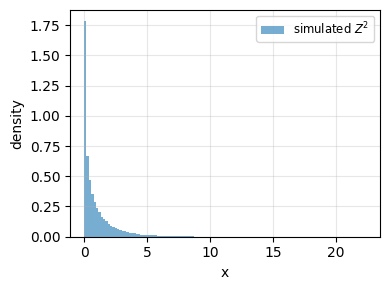

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

rng = np.random.default_rng(0)
n = 200000
z = rng.normal(0, 1, n)
x_sim = z**2  # Z^2 -> chi-square(1)

df = 1
x = np.linspace(0, chi2.ppf(0.999, df), 800)
pdf = chi2.pdf(x, df)

plt.figure(figsize=(4,3))
# plt.plot(x_sim, linewidth=2, label=r"theory $\chi^2_1$")
plt.hist(x_sim, bins=120, density=True, alpha=0.6, label="simulated $Z^2$")
# plt.ylim(0, 0.05)
# plt.plot(x, pdf, linewidth=2, label=r"theory $\chi^2_1$")
# plt.title(r"Simulation: $Z^2$ vs $\chi^2_1$")
plt.xlabel("x")
plt.ylabel("density")
plot_nicely()
plt.show()

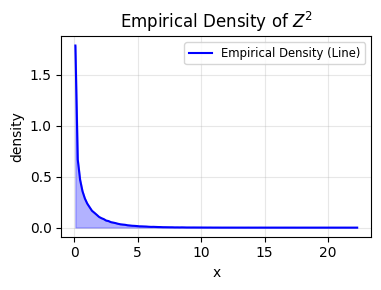

In [6]:
# 手动计算直方图和密度函数
counts, bins = np.histogram(x_sim, bins=120)
manual_density = counts / (counts.sum() * np.diff(bins))
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.figure(figsize=(4, 3))
plt.plot(bin_centers, manual_density, 'b-', label="Empirical Density (Line)")
plt.fill_between(bin_centers, manual_density, alpha=0.3, color='blue')
plt.title("Empirical Density of $Z^2$")
plt.xlabel("x")
plt.ylabel("density")
plot_nicely()
plt.show()

$$
\text{恒等式} \\
\bar{x} = \frac{1}{n} \sum x_i \\
\sum x_i = n\bar{x} \\
\quad \\

\sum (x_i - \bar{x})^2 = \sum (x_i - \bar{x})(x_i - \bar{x}) \\
= \sum (x_i^2 - 2x_i\bar{x} + \bar{x}^2) \\
= \sum x_i^2 - \sum 2x_i\bar{x} + \sum \bar{x}^2 \\
\quad \\

\text{处理第二项} \\
\sum 2x_i\bar{x} = 2\bar{x}\sum x_i = 2n\bar{x}^2 \\
\quad \\

\text{处理第三项} \\
\sum \bar{x}^2 = n\bar{x}^2 \\
\quad \\

\text{最终结果} \\
\sum (x_i - \bar{x})^2 = \sum x_i^2 - 2n\bar{x}^2 + n\bar{x}^2 \\
= \sum x_i^2 - n\bar{x}^2 \\
= \sum x_i^2 - \frac{1}{n}(\sum x_i)^2 \\
$$

In [7]:
((data - arithmetic_mean)**2).sum() == (data**2).sum() - 1 / data.size * (data.sum()**2)


np.True_

$$
\text{协方差 Covariance: 协方差表示X, Y随机变量的变化趋势是否一致} \\
COV > 0: \text{说明X和Y正相关, 即当X增加时, Y也增加} \\
COV < 0: \text{说明X和Y负相关, 即当X增加时, Y减少} \\
COV = 0: \text{说明X和Y独立, 即X的变化不影响Y的变化} \\
COV[x, y] = \frac{1}{n - 1} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) \\
\text{样本协方差计算时, 分母为n - 1. 总体协方差计算时, 分母为n.} \\ 
$$

In [8]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 4, 5, 7, 9])

# np.cov 给的是矩阵
# [Cov[X, X], Cov[X, Y]]
# [Cov[Y, X], Cov[Y, Y]]

sample_COV = 1 / (len(x) - 1) * np.sum((x - np.mean(x)) * (y - np.mean(y)))
sample_npCOV = np.cov(x, y, ddof=1)[0, 1]

total_COV = 1 / len(x) * np.sum((x - np.mean(x)) * (y - np.mean(y)))
total_npCOV = np.cov(x, y, ddof=0)[0, 1]

print(f'sample_COV: {sample_COV}')
print(f'sample_npCOV: {sample_npCOV}')
print(f'total_COV: {total_COV}')
print(f'total_npCOV: {total_npCOV}')


sample_COV: 2.75
sample_npCOV: 2.75
total_COV: 2.2
total_npCOV: 2.2


$$
\text{自协方差 (Auto Covariance)} \\
COV[x_t, x_{t + k}] = \frac{1}{n} \sum_{t=k}^{n} (x_t - \bar{x})(x_{t + k} - \bar{x}) \\
\text{k: 是滞后阶数 (Lags)或滞后步长或时间数} \\ \quad \\
\text{上面的自协方差是有偏估计，也就是真实数据其实只有k个，但平均时候用n个} \\
\text{所以无偏估计为} \\
COV[x_t, x_{t + k}] = \frac{1}{n - k} \sum_{t=k}^{n} (x_t - \bar{x})(x_{t + k} - \bar{x}) \\ \quad \\
\text{纯随机（白噪声）：如果你画出的散点图，除了 k=0（即方差）很大之外，其他的点都几乎在 0 附近晃荡} \\
\text{说明这个序列是纯随机的，不可预测。} \\ \quad \\
\text{有规律的序列：如果散点图呈现出平滑下降或震荡的趋势} \\
\text{说明历史数据对未来有参考价值，你可以用它来建立预测模型。} \\ \quad \\

\text{为什么要有（有偏估计）？} \\
\text{在实际的统计学和时间序列软件（如 R 或 Python 的 statsmodels）中，默认通常使用有偏估计（分母为 N）} \\
\text{正定性（Positive Definiteness）：使用分母 N可以保证得到的自协方差矩阵是“正定”的。} \\
\text{这意味着你算出的方差永远不会出现数学上的矛盾（比如算出负的方差）。} \\ \quad \\
\text{均方误差更小：虽然它有偏差，但在很多情况下，它的整体误差（均方误差）反而比无偏估计更小，尤其是在滞后阶数 k 较大时。} \\ \quad \\
\text{一致性：随着样本量 N 变得非常大，这两个公式的结果会趋于一致。} \\ \quad \\
\text{有偏估计大多在软件计算、工程实践中运用。而无偏估计在理论研究中更常用。} \\ \quad \\
$$


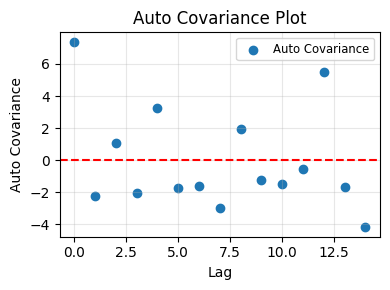

In [9]:
def calc_auto_cov(x, k):
    n = len(x)
    x_mean = np.mean(x)
    auto_cov = np.sum((x[:n-k] - x_mean) * (x[k:] - x_mean)) / (n - k)
    return auto_cov

x = np.array([1, 2, 6, 7, 2, 5, 7, 9, 4, 8, 2, 9, 1, 5, 6])
x_mean = np.mean(x)
auto_covs = [calc_auto_cov(x, k) for k in range(len(x))]
plt.figure(figsize=(4, 3))
plt.scatter(range(len(x)), auto_covs, label="Auto Covariance")
plt.axhline(0, color='r', linestyle='--')
plt.title("Auto Covariance Plot")
plt.xlabel("Lag")
plt.ylabel("Auto Covariance")
plot_nicely()
plt.show()

$$
\text{自相关系数 (Autocorrelation Coefficient)} \\
\rho_k = \frac{COV[x_t, x_{t + k}]}{\gamma_0} = \frac{\gamma_k}{\gamma_0} \\ \quad \\
\rho_k \text{ 是第 k 个滞后的自相关系数} \\
COV[x_t, x_{t + k}] \text{ 是第 k 个滞后的自协方差} \\ \quad \\
\text{所有的自相关系数组成的线，就叫做自相关函数 (AutoCorrelation Function)} \\
\text{ACF 实际上是} x_t \text{ 受到 } x_{t + 1}, x_{t + 2}, ..., x_{t + k - 1} \text{ 的影响} \\
\text{而这些 k - 1 个随机变量又都和 } x_{t + k} \text{ 具有相关关系} \\
\text{所以自相关系数里面实际掺杂了其他变量对 } x_t \text{ 与 } x_{t + k} \text{ 的影响} \\
$$

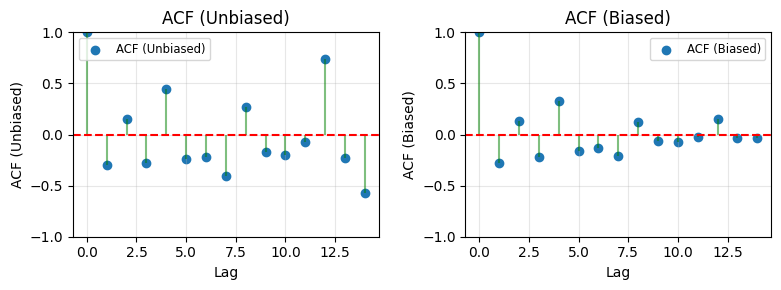

In [10]:
from statsmodels.tsa.stattools import acf

def calc_auto_correlation_coefficient(x, k):
    n = len(x)
    x_mean = np.mean(x)
    auto_correlation_coefficient = np.sum((x[:n-k] - x_mean) * (x[k:] - x_mean)) / (n - k)
    return auto_correlation_coefficient

x = np.array([1, 2, 6, 7, 2, 5, 7, 9, 4, 8, 2, 9, 1, 5, 6])
x_mean = np.mean(x)
acfs = [calc_auto_correlation_coefficient(x, k) / calc_auto_correlation_coefficient(x, 0) for k in range(len(x))]

fig, axs = plt.subplots(1, 2, figsize=(8, 3))
axs[0].scatter(range(len(x)), acfs, label="ACF (Unbiased)")
for i in range(len(x)):
    axs[0].vlines(i, 0, acfs[i], color='g', alpha=0.5)
axs[0].axhline(0, color='r', linestyle='--')
axs[0].set_title("ACF (Unbiased)")
axs[0].set_ylim(-1, 1)
axs[0].set_xlabel("Lag")
axs[0].set_ylabel("ACF (Unbiased)")

acf_func = acf(x, nlags=len(x)-1)
axs[1].scatter(range(len(x)), acf_func, label="ACF (Biased)")
for i in range(len(x)):
    axs[1].vlines(i, 0, acf_func[i], color='g', alpha=0.5)
axs[1].axhline(0, color='r', linestyle='--')
axs[1].set_title("ACF (Biased)")
axs[1].set_ylim(-1, 1)
axs[1].set_xlabel("Lag")
axs[1].set_ylabel("ACF (Biased)")

plot_nicely()
plt.show()

$$
\text{偏自相关系数 (Partial Autocorrelation Coefficient)} \\ \quad \\
\text{有四种方式计算偏自相关系数: } \\
\text{1. 把ACF 运用到 尤尔-沃克(Yule-Walker) 方程，再用矩阵求解法 (Cramer's Rule) 或者 递归算法 (Durbin-Levinson Algorithm)求解} \\
\text{2. 回归分析法 (Regression Approach)} \\
\text{3. 残差相关法 (Residual Correlation)} \\
\text{4. 最大似然估计法 (Maximum Likelihood Estimation)} \\
$$

In [11]:
from scipy.linalg import toeplitz

# 把 ACF 运用到 尤尔-沃克(Yule-Walker) 方程
lags = 3
yule_walker_eq = toeplitz(acfs[:lags])
phi = acfs[1:lags+1] @ np.linalg.inv(yule_walker_eq)
print(f'phi = {phi}')

phi = [-0.26288878  0.00004557 -0.23665937]


In [12]:
# apply Cramer's Rule
numerator = yule_walker_eq.copy()
numerator[:, -1] = acfs[1:lags+1]
denominator = yule_walker_eq
np.linalg.det(numerator) / np.linalg.det(denominator)

np.float64(-0.23665937223917904)

In [13]:
# 可视化 Durbin-Levinson 算法
def visual_durbin_levinson(acfs, p):
    phi = np.zeros((p, p))
    rho = acfs 
    
    print(f"🚀 开始拟合 AR({p}) 模型...")
    print("-" * 50)
    
    # 第 1 阶初始化
    phi[0, 0] = rho[1]
    print(f"阶数 k=1: 直接取自相关系数 ρ₁")
    print(f"   φ₁₁ = {phi[0,0]:.4f}")
    
    # 递推
    for k in range(2, p + 1):
        # 计算当前阶的偏自相关系数 (PACF)
        prev_coeffs = phi[k-2, :k-1]
        relevant_rhos_num = rho[1:k][::-1]
        relevant_rhos_den = rho[1:k]
        
        num = rho[k] - np.dot(prev_coeffs, relevant_rhos_num)
        den = 1 - np.dot(prev_coeffs, relevant_rhos_den)
        phi_kk = num / den
        
        phi[k-1, k-1] = phi_kk
        
        print(f"\n阶数 k={k}:")
        print(f"   Step 1: 计算主系数 (PACF) φ_{k}{k}")
        print(f"     φ_{k}{k} = ({rho[k]:.4f} - 修正项) / 误差压缩项 = {phi_kk:.4f}")
        
        # 更新之前的系数
        print(f"   Step 2: 利用 φ_{k}{k} 修正前 {k-1} 个系数")
        for j in range(1, k):
            old_val = phi[k-2, j-1]
            phi[k-1, j-1] = old_val - phi_kk * phi[k-2, k-j-1]
            print(f"     φ_{k}{j} = {old_val:.4f} - ({phi_kk:.4f} * {phi[k-2, k-j-1]:.4f}) -> {phi[k-1, j-1]:.4f}")
        
        print(f"phi = \n{phi}")
            
    print("-" * 50)
    print(f"✅ 最终 AR({p}) 系数向量: {phi[p-1]}")
    return phi[p-1]


visual_durbin_levinson(acfs, lags)


🚀 开始拟合 AR(3) 模型...
--------------------------------------------------
阶数 k=1: 直接取自相关系数 ρ₁
   φ₁₁ = -0.2982

阶数 k=2:
   Step 1: 计算主系数 (PACF) φ_22
     φ_22 = (0.1490 - 修正项) / 误差压缩项 = 0.0660
   Step 2: 利用 φ_22 修正前 1 个系数
     φ_21 = -0.2982 - (0.0660 * -0.2982) -> -0.2785
phi = 
[[-0.29816277  0.          0.        ]
 [-0.27849756  0.06595463  0.        ]
 [ 0.          0.          0.        ]]

阶数 k=3:
   Step 1: 计算主系数 (PACF) φ_33
     φ_33 = (-0.2758 - 修正项) / 误差压缩项 = -0.2367
   Step 2: 利用 φ_33 修正前 2 个系数
     φ_31 = -0.2785 - (-0.2367 * 0.0660) -> -0.2629
     φ_32 = 0.0660 - (-0.2367 * -0.2785) -> 0.0000
phi = 
[[-0.29816277  0.          0.        ]
 [-0.27849756  0.06595463  0.        ]
 [-0.26288878  0.00004557 -0.23665937]]
--------------------------------------------------
✅ 最终 AR(3) 系数向量: [-0.26288878  0.00004557 -0.23665937]


array([-0.26288878,  0.00004557, -0.23665937])

In [14]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# 回归分析法
def pacf_via_regression(data, nlags=10):
    pacf_results = [1.0]  # Lag 0 默认为 1
    n_total = len(data)   # 定义总样本量
    
    for k in range(1, nlags + 1):
        # 1. 准备 y (从第 k 个元素开始)
        y = data[k:]
        
        # 2. 构建特征矩阵 [X_{t-1}, ..., X_{t-k}]
        # 修正原代码中的 n 为 n_total
        X_matrix = np.array([data[k-i : n_total-i] for i in range(1, k+1)]).T
        
        # 3. 关键点：加入截距项 (如果不加，数据未中心化会导致结果偏差)
        X_matrix = add_constant(X_matrix)
        
        # 4. 拟合模型
        model = OLS(y, X_matrix).fit()
        
        # 5. 取最后一个滞后项的系数 (params[0]是截距，params[-1]是第k个滞后项)
        pacf_results.append(model.params[-1])
        
    return np.array(pacf_results)

pacf = pacf_via_regression(x, lags)
print(f'PACF = {pacf}')

PACF = [ 1.         -0.27864583  0.00536425 -0.22536923]


In [15]:
from sklearn.linear_model import LinearRegression

def pacf_via_residuals(data, lags):
    n = len(data)
    if lags <= 1:
        # 1阶PACF等于1阶ACF，没有中间项
        return np.corrcoef(data[1:], data[:-1])[0, 1]

    # 1. 准备数据
    y_present = data[lags:]            # X_t
    y_past = data[:n-lags]             # X_{t-k}
    
    # 2. 构建中间项矩阵 (X_{t-1} 到 X_{t-k+1})
    # 每一列是一个滞后项，行数需与 y_present 一致
    mid_terms = np.array([data[lags-i : n-i] for i in range(1, lags)]).T

    # 3. 步骤 A：用 X_{t-1...t-k+1} 预测 X_t，取残差
    model_t = LinearRegression().fit(mid_terms, y_present)
    res_t = y_present - model_t.predict(mid_terms)

    # 4. 步骤 B：用 X_{t-1...t-k+1} 预测 X_{t-k}，取残差
    model_tk = LinearRegression().fit(mid_terms, y_past)
    res_tk = y_past - model_tk.predict(mid_terms)

    # 5. 步骤 C：计算残差的相关系数
    return np.corrcoef(res_t, res_tk)[0, 1]


pacf = pacf_via_residuals(x, lags)
print(f'PACF = {pacf}')

PACF = -0.2626085306801693


$$
\text{皮尔逊相关系数（Pearson correlation coefficient）} \\
\text{衡量两个变量之间线性相关程度的统计指标} \\ \quad \\
r = \frac{COV(X, Y)}{\sigma_X\sigma_Y}
$$

In [16]:
x_data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_data = np.array([5, 4, 5, 7, 9, 8, 10, 12, 11, 13])

sample_cov = np.cov(x_data, y_data, ddof=1)[0, 1]
stdev_x = x_data.std(ddof=1)
stdev_y = y_data.std(ddof=1)
pearson_correlation_coefficient = sample_cov / (stdev_x * stdev_y)
print(f'Pearson Correlation Coefficient = {pearson_correlation_coefficient}')
print(f'Pearson Correlation Coefficient (np.corrcoef) = {np.corrcoef(x_data, y_data)[0, 1]}')

Pearson Correlation Coefficient = 0.9601978862731942
Pearson Correlation Coefficient (np.corrcoef) = 0.960197886273194


$$
\text{最大似然估计 (Maximum Likelihood Estimation MLE)} \\
\text{是一种基于已知观测数据来估计统计模型未知参数的方法。其核心思想是寻找使当前样本数据出现概率最大化的参数值。} \\
\text{MLE 通过构建似然函数，通常利用对数似然函数求导或优化算法，找到令观测结果“可能性”最大的参数估计值。} \\ \quad \\

\text{似然函数 (Likelihood Function)} \\
\text{对于离散结果, 似然函数为各个结果概率的出现次数的幂次方} \\
L = \prod_{i=1}^n p(x_i | \theta) \\ \quad \\
\text{对于连续变量, 似然函数为所有样本点的概率密度函数的乘积} \\
L = \prod_{i=1}^n f(x_i | \theta) \\
$$

$$
\text{由离散数据组成的函数叫概率质量函数 (Probability Mass Function)} \\
\sum P(x_i) = 1 \\
\text{由连续变量组成的函数叫概率密度函数 (Probability Density Function)} \\ 
\int_{-\infty}^{\infty} f(x)dx = 1 \\
\quad \\

\text{概率质量函数可以在单点知道该事件发生的概率} \\
\text{概率密度函数只能在区间内知道该区间事件发生的概率} \\ \quad \\
$$

In [17]:
discrete_points = np.array([1, 3, 5, 7, 9, 3, 5, 9, 11])
n = discrete_points.size
diff_n = len(set(discrete_points))
p = np.zeros(diff_n)
for i in range(diff_n):
    p[i] = np.sum(discrete_points == list(set(discrete_points))[i])
    
likelihood = np.prod(p)
log_likelihood = np.sum(np.log(p))

print(f'离散点 {discrete_points}')
print(f'离散点的 所有概率总和为 {np.sum(p / n)}')
print(f'离散点的 似然值为 {likelihood}')
print(f'离散点的 对数似然为 {log_likelihood} \n')

def continuous_function(x, a, b):
    return a * x + b
def integral_of_continuous_function(x, a, b):
    return a / 2 * x**2 + b * x
continuous_points = np.array([1.4, 3.2, 1.5, 5.7, 4.9, 5.2, 6.4, 9.1])
continuous_points.sort()
continuous_points /= 10

a, b = 1.3, 10

# 归一化
area = integral_of_continuous_function(continuous_points[-1], a, b) - integral_of_continuous_function(continuous_points[0], a, b)

pdf_at_point = continuous_function(continuous_points, a, b) / area

likelihood = np.prod(pdf_at_point)
log_likelihood = np.sum(np.log(pdf_at_point))

print(f'连续点 {continuous_points}')
print(f'连续点的 所有概率总和为 {area}')
print(f'连续点的 似然值为 {likelihood}')
print(f'连续点的 对数似然为 {log_likelihood}')


离散点 [ 1  3  5  7  9  3  5  9 11]
离散点的 所有概率总和为 1.0
离散点的 似然值为 8.0
离散点的 对数似然为 2.0794415416798357 

连续点 [0.14 0.15 0.32 0.49 0.52 0.57 0.64 0.91]
连续点的 所有概率总和为 8.225525
连续点的 似然值为 7.623452487245057
连续点的 对数似然为 2.0312293494033797


$$
\text{如果说回归方程是根据数据找到模型的参数，那似然函数是根据模型的参数来找出最匹配数据的方法} \\
\text{以下是例子} \\
\text{定义AR(1) 模型} \\
X_t = \phi X_{t-1} + \epsilon_t \\
\text{假设噪声服从标准正态分布} (\sigma = 1) \\ \quad \\
\text{我们的目标是找到} \phi \text{, 使得 } \ell(\phi) = \sum - \frac{1}{2}(X_t - \phi X_{t-1})^2 \text{ 最大} \\ \quad \\
$$

扫描完成！最佳参数 phi: 0.6565656565656566
最大对数似然值: -7.577344658708296
扫描完成！最佳参数 phi: -0.5555555555555554
最大对数似然值: -12.435925925925927
扫描完成！最佳参数 phi: -1.0606060606060606
最大对数似然值: -7.70564738292011
扫描完成！最佳参数 phi: 0.050505050505050164
最大对数似然值: -14.057641057034996
扫描完成！最佳参数 phi: 1.8686868686868685
最大对数似然值: -2.9052969084787263
扫描完成！最佳参数 phi: 0.45454545454545414
最大对数似然值: -12.15020661157025
扫描完成！最佳参数 phi: -2.070707070707071
最大对数似然值: -5.12824456688093


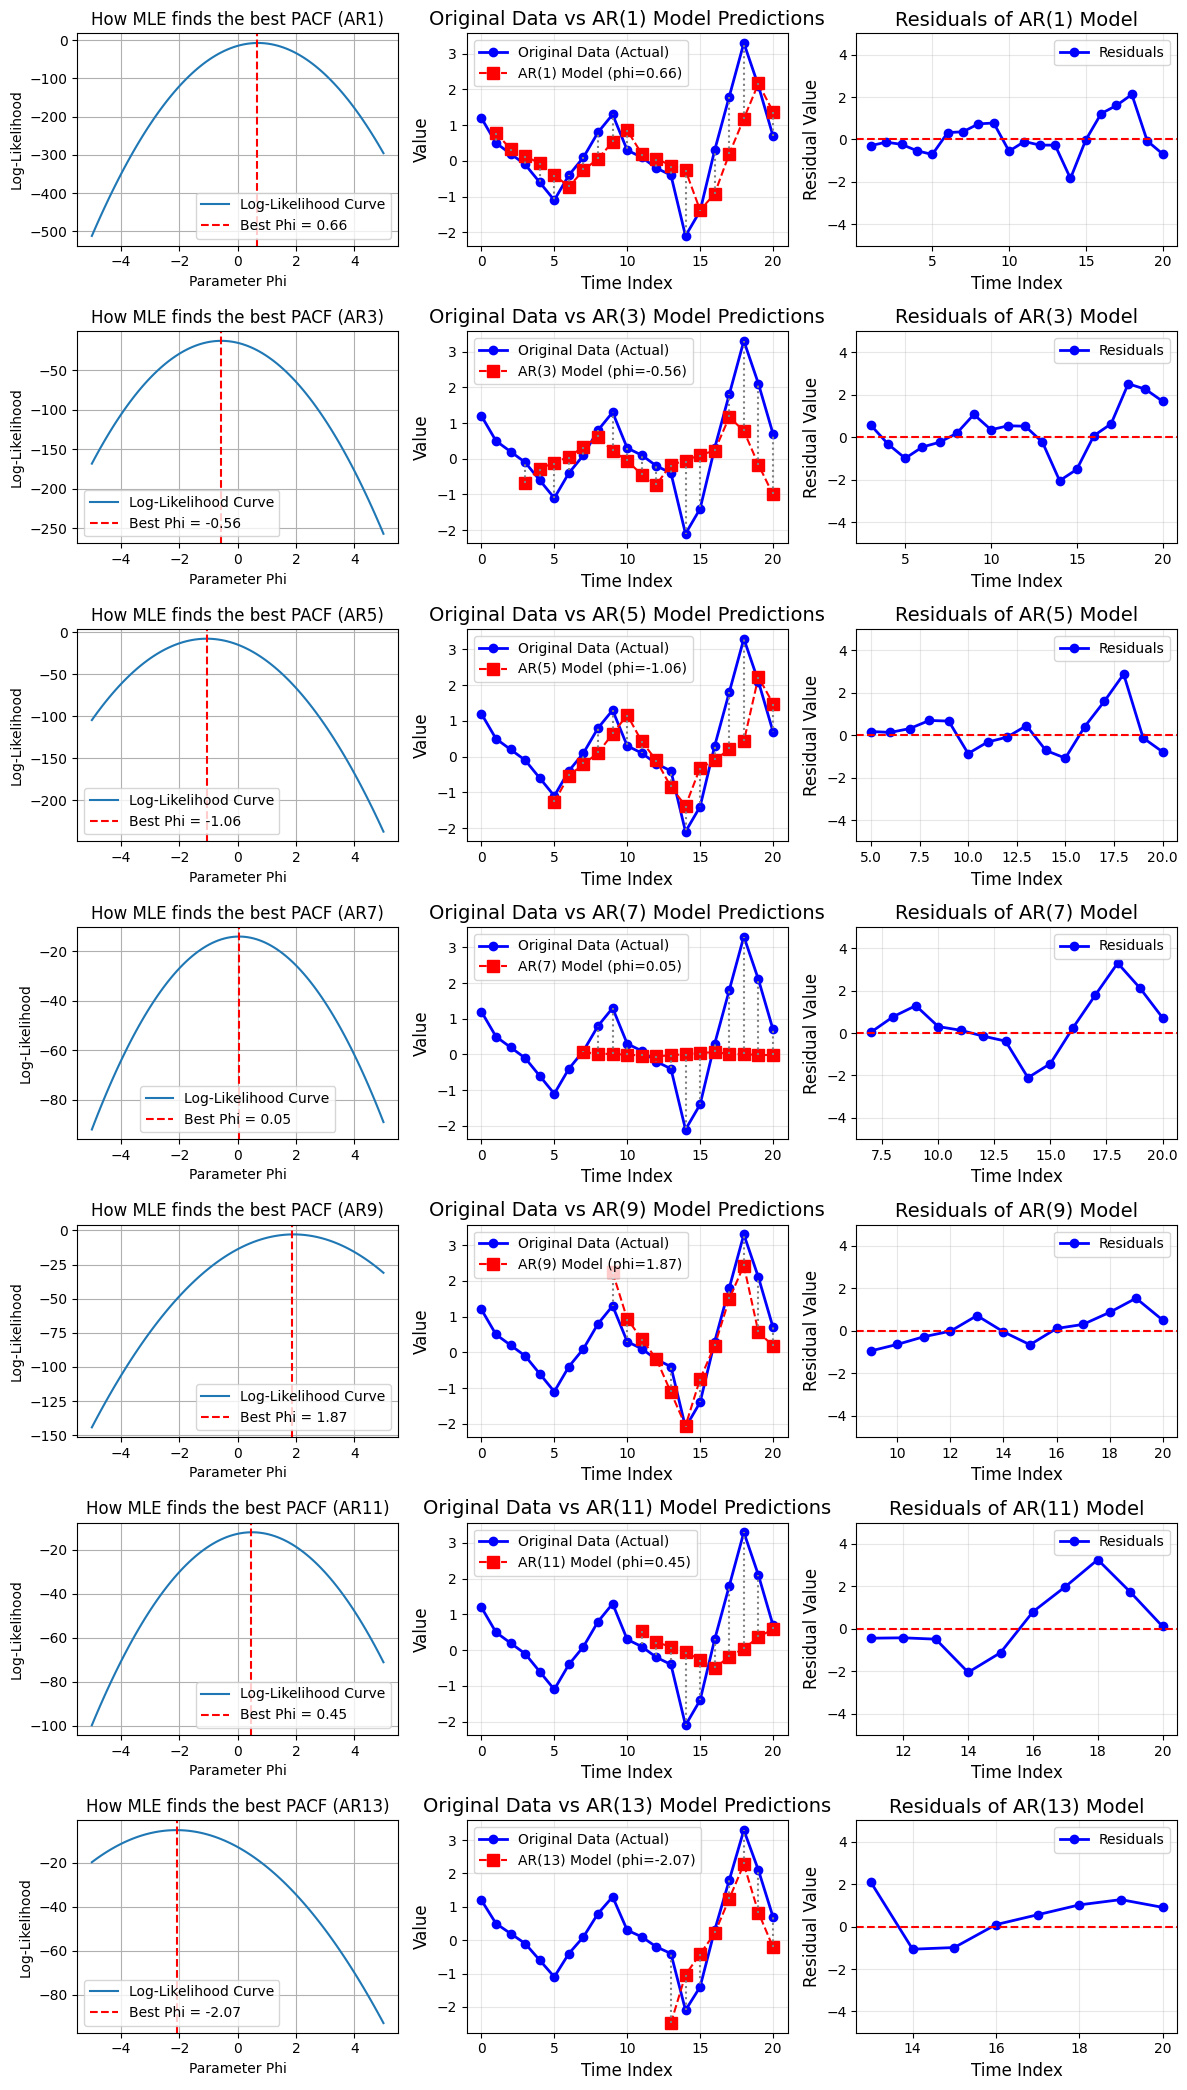

In [22]:
data = np.array([1.2, 0.5, 0.2, -0.1, -0.6, -1.1, -0.4, 0.1, 0.8, 1.3, 0.3, 0.1, -0.2, -0.4, -2.1, -1.4, 0.3, 1.8, 3.3, 2.1, 0.7])
lag = [1, 3, 5, 7, 9, 11, 13]
def calculate_log_likelihood(phi, data, lag):
    """
    针对 AR(1) 模型计算条件对数似然
    公式: LL = sum( -0.5 * log(2*pi*sigma^2) - (x_t - phi*x_{t-1})^2 / (2*sigma^2) )
    为了简化观察，我们假设噪声标准差 sigma = 1
    """
    x_present = data[lag:]  # X_t
    x_past = data[:-lag]    # X_{t-1}
    
    # 计算残差
    residuals = x_present - phi * x_past
    
    # 计算对数似然 (省略常数项，只关注与 phi 相关的部分)
    log_likelihood = -0.5 * np.sum(residuals**2)
    return log_likelihood

# 4. 可视化过程
fig, axs = plt.subplots(7, 3, figsize=(12, 21))
for i in range(7):
    # 2. 尝试不同的参数值 (从 -1.5 到 1.5 扫描)
    phi_candidates = np.linspace(-5, 5, 100)
    ll_values = [calculate_log_likelihood(p, data, lag[i]) for p in phi_candidates]

    # 3. 找到使对数似然最大的参数
    best_phi = phi_candidates[np.argmax(ll_values)]
    max_ll = max(ll_values)

    print(f"扫描完成！最佳参数 phi: {best_phi}")
    print(f"最大对数似然值: {max_ll}")
    
    axs[i, 0].plot(phi_candidates, ll_values, label='Log-Likelihood Curve')
    axs[i, 0].axvline(best_phi, color='r', linestyle='--', label=f'Best Phi = {best_phi:.2f}')
    axs[i, 0].set_title(f"How MLE finds the best PACF (AR{lag[i]})")
    axs[i, 0].set_xlabel("Parameter Phi")
    axs[i, 0].set_ylabel("Log-Likelihood")
    axs[i, 0].legend()
    axs[i, 0].grid(True)

    axs[i, 1].plot(range(len(data)), data, 'bo-', label='Original Data (Actual)', linewidth=2)
    predicted = best_phi * data[:-lag[i]]
    axs[i, 1].plot(range(lag[i], len(data)), predicted, 'rs--', label=f'AR({lag[i]}) Model (phi={best_phi:.2f})', markersize=8)
    for j in range(lag[i], len(data)):
        axs[i, 1].vlines(j, predicted[j-lag[i]], data[j], colors='gray', linestyles='dotted')

    axs[i, 1].set_title(f"Original Data vs AR({lag[i]}) Model Predictions", fontsize=14)
    axs[i, 1].set_xlabel("Time Index", fontsize=12)
    axs[i, 1].set_ylabel("Value", fontsize=12)
    axs[i, 1].legend()
    axs[i, 1].grid(True, alpha=0.3)

    residuals = data[lag[i]:] - best_phi * data[:-lag[i]]
    axs[i, 2].plot(range(lag[i], len(data)), residuals, 'bo-', label='Residuals', linewidth=2)
    axs[i, 2].axhline(0, color='r', linestyle='--')
    axs[i, 2].set_title(f"Residuals of AR({lag[i]}) Model", fontsize=14)
    axs[i, 2].set_xlabel("Time Index", fontsize=12)
    axs[i, 2].set_ylabel("Residual Value", fontsize=12)
    axs[i, 2].set_ylim(-5, 5)
    axs[i, 2].legend()
    axs[i, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

$$
\text{接下来用MLE 来解 PACF} \\
\text{MLE的假设下，如果误差服从正态分布，那么似然函数的损失函数 (Loss function) 等同于残差平方和 (RSS 或者 SSE)} \\
\text{MLE 即最小化这个损失函数} \\
\text{k 阶自回归模型的预测值为: } \\
\hat{x}_t = \phi_1 x_{t-1} + \phi_2 x_{t-2} + \cdots + \phi_k x_{t-k} = \sum_{i=1}^{k} \phi_i x_{t-i} \\ \quad \\
\text{损失函数 } \textbf{J} (\Phi) 定义为所有样本预测误差的平方均值: \\
\textbf{J}(\phi_1, \phi_2, \cdots, \phi_k) = \frac{1}{2(n-k)} \sum_{t=k+1}^{n} \left( x_t - \hat{x}_t \right)^2 \\ \quad \\
\text{梯度是损失函数对每个参数的偏导数组成的向量。它指向函数增长最快的方向，因此我们取其反方向来寻找最小值。} \\
\text{我们要对其中的某一个参数 } \phi_j \text{ 其中 } j \in \{1, 2, \cdots, k\} \text{ 求偏导} \\
\frac{\partial J}{\partial \phi_j} = \frac{\partial}{\partial \phi_j} \left[ \frac{1}{2(n-k)} \sum_{t=k+1}^{n} \left( x_t - \hat{x}_t \right)^2 \right] \\ \quad \\
\text{利用链式法则(求导嵌套): } \\
\text{1. 先对外部平方项求导: } 2 \times (x_t - \hat{x}_t) \\
\text{2. 再对括号内部的: } -\hat{x}_t \text{ 关于 } \phi_j \text{ 求导} \\
\text{因为 } \hat{x}_t = \phi_1x_{t-1} + \phi_2x_{t-2} + \cdots + \phi_kx_{t-k} \\
\text{所以 } \frac{\partial \left(x_t - \hat{x}_t\right)}{\partial \phi_j} = -x_{t-j} \\ \quad \\
\text{将两部分组合起来: } \\
\frac{\partial J}{\partial \phi_j} = \frac{1}{n-k} \sum_{t=k+1}^{n} \left( x_t - \hat{x}_t \right) \left( -x_{t-j} \right) \\ \quad \\
\text{为了方便代码实现，我们通常写成: } \\
\frac{\partial J}{\partial \phi_j} = -\frac{1}{n-k} \sum_{t=k+1}^{n} \underbrace{\left(x_t - \hat{x}_t\right)}_{\text{残差/误差}} \underbrace{\left( x_{t-j} \right)}_{\text{对应的输入}} \\ \quad \\
\text{这个公式非常有美感，它告诉我们：参数 } \phi_j \text{ 的调整方向，取决于“前j个数据的误差”与“该参数对应的滞后项输入”的相关性。}
$$

$$
\ell \\ \quad \\
\mathscr{A} \quad \mathscr{B} \quad \mathscr{C} \quad \mathscr{D} \quad \mathscr{E} \quad \mathscr{F} \quad \mathscr{G} \quad \mathscr{H} \quad \mathscr{I} \quad \mathscr{J} \quad \mathscr{K} \quad \mathscr{L} \quad \mathscr{M} \quad \mathscr{N} \quad \mathscr{O} \quad \mathscr{P} \quad \mathscr{Q} \quad \mathscr{R} \quad \mathscr{S} \quad \mathscr{T} \quad \mathscr{U} \quad \mathscr{V} \quad \mathscr{W} \quad \mathscr{X} \quad \mathscr{Y} \quad \mathscr{Z} \\ \quad \\
\mathcal{a} \quad \mathcal{b} \quad \mathcal{c} \quad \mathcal{d} \quad \mathcal{e} \quad \mathcal{f} \quad \mathcal{g} \quad \mathcal{h} \quad \mathcal{i} \quad \mathcal{j} \quad \mathcal{k} \quad \mathcal{l} \quad \mathcal{m} \quad \mathcal{n} \quad \mathcal{o} \quad \mathcal{p} \quad \mathcal{q} \quad \mathcal{r} \quad \mathcal{s} \quad \mathcal{t} \quad \mathcal{u} \quad \mathcal{v} \quad \mathcal{w} \quad \mathcal{x} \quad \mathcal{y} \quad \mathcal{z} \\ \quad \\
\mathfrak{A} \quad \mathfrak{B} \quad \mathfrak{C} \quad \mathfrak{D} \quad \mathfrak{E} \quad \mathfrak{F} \quad \mathfrak{G} \quad \mathfrak{H} \quad \mathfrak{I} \quad \mathfrak{J} \quad \mathfrak{K} \quad \mathfrak{L} \quad \mathfrak{M} \quad \mathfrak{N} \quad \mathfrak{O} \quad \mathfrak{P} \quad \mathfrak{Q} \quad \mathfrak{R} \quad \mathfrak{S} \quad \mathfrak{T} \quad \mathfrak{U} \quad \mathfrak{V} \quad \mathfrak{W} \quad \mathfrak{X} \quad \mathfrak{Y} \quad \mathfrak{Z} \\ \quad \\
\mathfrak{a} \quad \mathfrak{b} \quad \mathfrak{c} \quad \mathfrak{d} \quad \mathfrak{e} \quad \mathfrak{f} \quad \mathfrak{g} \quad \mathfrak{h} \quad \mathfrak{i} \quad \mathfrak{j} \quad \mathfrak{k} \quad \mathfrak{l} \quad \mathfrak{m} \quad \mathfrak{n} \quad \mathfrak{o} \quad \mathfrak{p} \quad \mathfrak{q} \quad \mathfrak{r} \quad \mathfrak{s} \quad \mathfrak{t} \quad \mathfrak{u} \quad \mathfrak{v} \quad \mathfrak{w} \quad \mathfrak{x} \quad \mathfrak{y} \quad \mathfrak{z} \\ \quad \\


$$
\text{离散型随机变量的数学期望 (Expectation)} \\
E(X) = \sum_{i=1}^n x_i p(x_i) \\
\quad \\
\text{连续型随机变量的数学期望 (Expectation)} \\
E(X) = \int_{-\infty}^{\infty} x f(x) dx \\
$$

In [19]:
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])
discret_E = np.sum(x * p)
discret_E == x.mean()

np.True_

Mathematical Expectation: 1.3333333333333335


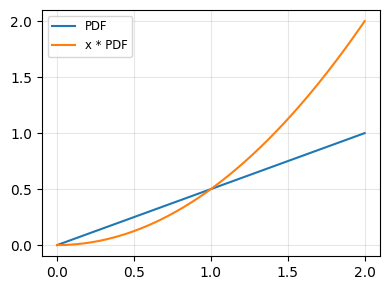

In [20]:
from scipy.integrate import quad

x = np.linspace(0, 2, 400)

# 1. 定义合法的概率密度函数 (PDF)
def f(x):
    return 0.5 * x

# 2. 定义期望的被积函数：x * f(x)
def expectation_integrand(x):
    return x * f(x)

# 3. 使用积分函数计算期望
# quad 函数返回 (积分值, 误差估计)
expected_value, error = quad(expectation_integrand, 0, 2)

print(f"Mathematical Expectation: {expected_value}") 
# 结果为 1.333... (即 4/3)
# 注意：这比区间的算术中点 1.0 更偏右，因为右侧的概率密度更大。

plt.figure(figsize=(4, 3))
plt.plot(x, f(x), label='PDF')
plt.plot(x, expectation_integrand(x), label='x * PDF')
plot_nicely()
plt.show()
